# Evaluasi Hybrid CAG-RAG — Wisata Danau Toba

Judul: *Analysis of Hybrid CAG-RAG for Reducing Retrieval Latency and Retrieval Inaccuracy in RAG-Based Recommendation Systems*

### Research Questions
1. **RQ1 (Latency):** Bagaimana cara menangani masalah retrieval latency pada sistem RAG?
2. **RQ2 (Relevance):** Sejauh mana perbedaan relevansi hasil retrieval Hybrid CAG-RAG vs RAG?

### Metrik

| Kategori | Metrik | RQ |
|----------|--------|----|
| Latency | Response Time, Cache Hit Rate, Speedup Factor | RQ1 |
| Relevansi | Relevance Score, Completeness | RQ2 |
| Akurasi | Exact Match, Token F1 | RQ2 |
| Kualitas | BERTScore F1 | RQ2 |
| Inaccuracy | Hallucination Rate | RQ2 |
| Statistik | Paired t-test, Cohen's d | Validasi |

### Skenario

| Skenario | Sistem | Deskripsi |
|----------|--------|-----------|
| FAQ | CAG | Query dari FAQ static cache |
| KV_Cache | CAG | Query baru via RAG, disimpan ke KV-Cache, diulang untuk ukur speedup |
| RAG | RAG | Pure retrieval, tanpa cache |

FAQ + KV_Cache = sistem CAG (Cache-Augmented Generation).

## Setup Environment

In [8]:
# Install Dependencies
%pip install -q python-dotenv sentence-transformers langchain langchain-community faiss-cpu bert-score pandas matplotlib seaborn scipy nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Setup & Imports
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from scipy import stats
import scipy
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
from bert_score import score as bert_score_fn
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv

# -- Path & env ------------------------------------------------------------
sys.path.append(os.path.abspath('../src'))
load_dotenv()

# -- Import evaluation classes dari evaluation.py -------------------------
from evaluation import QuantitativeMetrics, PerformanceEvaluator, QueryMetrics

# -- Plot style -----------------------------------------------------------
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("✅ Setup complete")
print(f"   scipy        : {scipy.__version__}")
print(f"   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded")


✅ Setup complete
   scipy        : 1.17.0
   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded


## Load Model & Encoder
- LLM: Gemini 2.5 Flash via Google REST API
- Encoder: `paraphrase-multilingual-MiniLM-L12-v2` (multilingual embedding)

In [10]:
# Load Model & Encoder (digunakan oleh seluruh notebook)
from model import GeminiChatModel
from langchain_community.embeddings import HuggingFaceEmbeddings

gemini = GeminiChatModel(model_name="gemini-2.5-flash")

encoder = HuggingFaceEmbeddings(
    model_name="paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True},
)

print("Model   : gemini-2.5-flash")
print(f"API keys: {len(gemini.api_keys)}")
print("Encoder : paraphrase-multilingual-MiniLM-L12-v2")


🔍 Initializing Gemini API: gemini-2.5-flash
🔑 API keys available: 1
⏱️ Rate limit protection: 5s between requests
🔄 Context-based fallback: ENABLED
Model   : gemini-2.5-flash
API keys: 1
Encoder : paraphrase-multilingual-MiniLM-L12-v2


In [19]:
# ============================================================
# QUICK TEST — Gemini 2.5 Flash API
# Jalankan cell ini SEBELUM cell lainnya untuk memastikan
# API key valid dan gemini-2.5-flash dapat merespons.
# Cell ini berdiri sendiri — tidak butuh cell sebelumnya.
# ============================================================
import sys, os, io, contextlib
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "src"))
sys.path.insert(0, "../src")

from dotenv import load_dotenv
load_dotenv("../.env")

from model import GeminiChatModel

print("=" * 50)
print("Quick Test: Gemini 2.5 Flash API")
print("=" * 50)

gemini_test = GeminiChatModel(model_name="gemini-2.5-flash")

_test_prompt = "Sebutkan satu tempat wisata terkenal di Danau Toba. Jawab dalam 1-2 kalimat."

_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    _resp = gemini_test._call_gemini_api(_test_prompt, max_tokens=100)
_log = _buf.getvalue()

active_model = None
for _line in _log.splitlines():
    if "Response from" in _line:
        active_model = _line.split("Response from")[-1].strip().split()[0]
        break

print(f"\nHasil:")
print(f"  API key     : {len(gemini_test.api_keys)} key ditemukan")
print(f"  Model aktif : {active_model or 'tidak terdeteksi'}")
print(f"  Response    : {repr(_resp[:80]) if _resp else None}")

if _resp and active_model and "2.5-flash" in active_model:
    print("\nSIAP: gemini-2.5-flash berjalan normal, lanjutkan ke cell berikutnya")
elif _resp and active_model:
    print(f"\nFALLBACK: yang merespons {active_model} (bukan 2.5-flash)")
    print("  Kemungkinan: quota 2.5-flash habis atau key belum valid")
else:
    print("\nGAGAL: API tidak merespons")
    print("  Cek: GEMINI_API_KEY di .env sudah benar?")
    print(_log)


Quick Test: Gemini 2.5 Flash API
🔍 Initializing Gemini API: gemini-2.5-flash
🔑 API keys available: 1
⏱️ Rate limit protection: 5s between requests
🔄 Context-based fallback: ENABLED

Hasil:
  API key     : 1 key ditemukan
  Model aktif : gemini-2.5-flash
  Response    : 'Salah satu tempat wisata terkenal di Danau Toba adalah Pulau Samosir. Pulau ini '

SIAP: gemini-2.5-flash berjalan normal, lanjutkan ke cell berikutnya


## Build Knowledge Base

In [12]:
# Load Documents & Build Vector DB
tourism_dir = os.path.abspath('../database/documents')
pdf_files   = [os.path.join(tourism_dir, f)
               for f in os.listdir(tourism_dir) if f.endswith('.pdf')] \
              if os.path.exists(tourism_dir) else []

pages = [p for pdf in pdf_files for p in PyPDFLoader(pdf).load()]
# chunk_size=768, overlap=100 — sinkron dengan hybrid_system.py
docs  = RecursiveCharacterTextSplitter(chunk_size=768, chunk_overlap=100).split_documents(pages) if pages else []
faiss_db = FAISS.from_documents(docs, encoder) if docs else None

if pdf_files:
    print(f"✅ {len(pdf_files)} PDFs → {len(docs)} chunks  ({tourism_dir})")
    for p in pdf_files:
        print(f"   - {os.path.basename(p)}")
else:
    print(f"⚠️  Tidak ada PDF di {tourism_dir}")
    print("   Letakkan file PDF wisata ke folder database/documents/")


✅ 4 PDFs → 224 chunks  (d:\Semester 8\TA II\Implementasi\database\documents)
   - data rumah makan.pdf
   - hotel.pdf
   - transportasi.pdf
   - wisata.pdf


## Setup CAG System

In [13]:
# Setup CAG System (Hybrid CAG-RAG)
try:
    from hybrid_system import CAGSystem   # nama modul yang benar
    cag = CAGSystem(gemini, encoder)
    if pdf_files:
        cag.load_documents(pdf_files, use_summaries=False)
    cag_ok = True
    print("✅ CAG System (Hybrid CAG-RAG) ready")
    print(f"   Confirmed cache entries : {len(cag.kv_cache.cache)}")
    print(f"   Staging entries         : {len(cag.kv_cache.staging)}")
except Exception as e:
    cag_ok = False
    print(f"⚠️  CAG not available: {e}")

📚 Loading 4 documents for CAG...
   ✅ Loaded: data rumah makan.pdf (21 halaman)
   ✅ Loaded: hotel.pdf (29 halaman)
   ✅ Loaded: transportasi.pdf (5 halaman)
   ✅ Loaded: wisata.pdf (31 halaman)
🔍 Splitting into chunks...
📄 Loaded 86 halaman dari 4 file, split into 231 chunks
🔨 Building vector database...
✅ CAG ready: 231 chunks in 27.93s
✅ CAG System (Hybrid CAG-RAG) ready
   Confirmed cache entries : 0
   Staging entries         : 0


## Test Dataset

In [14]:
# === Dataset Evaluasi ===
# Prioritas 1 : load dari FAQ (ground truth resmi, entries yang punya 'answer')
# Prioritas 2 : fallback ke 5 sample queries jika FAQ belum punya 'answer'

# ── Konfigurasi ─────────────────────────────────────────────────────────────
# Batasi jumlah query untuk evaluasi agar tidak terlalu lama.
# 30 query cukup representatif; naikkan ke 50-100 jika punya waktu lebih.
MAX_QUERIES = 30
# ─────────────────────────────────────────────────────────────────────────────

faq_path = os.path.abspath('../database/FAQ/faq_tourism.json')
dataset  = []

if os.path.exists(faq_path):
    with open(faq_path, 'r', encoding='utf-8') as _f:
        _faq_data = json.load(_f)

    # Gunakan hanya FAQ yang sudah memiliki field 'answer' sebagai ground truth
    dataset = [
        {
            "q":  faq["question"],
            "gt": faq["answer"],
            "kw": faq.get("keywords", []),
        }
        for faq in _faq_data
        if faq.get("answer", "").strip()
    ]

    if dataset:
        print(f"✅ Loaded {len(dataset)} FAQ entries (dengan 'answer') sebagai ground truth")
        print(f"   Contoh: Q={dataset[0]['q'][:50]}")
        print(f"           GT={dataset[0]['gt'][:60]}")
    else:
        print("⚠️  FAQ ditemukan tapi belum ada field 'answer'.")
        print("   Jalankan proses pengisian answer di FAQ terlebih dahulu.")

# Fallback: 5 sample queries jika FAQ belum ada jawaban
if not dataset:
    dataset = [
        {"q": "Rekomendasi wisata Danau Toba untuk keluarga?",
         "gt": "Pulau Samosir, Museum Huta Bolon, Pantai Parapat, Desa Tomok.",
         "kw": ["Samosir", "Parapat", "wisata", "Batak"]},
        {"q": "Biaya homestay di Danau Toba?",
         "gt": "Rp 150.000 - Rp 500.000 per malam.",
         "kw": ["homestay", "biaya", "Rp"]},
        {"q": "Makanan khas Batak apa saja?",
         "gt": "Saksang, Arsik, Naniura, Dali ni Horbo.",
         "kw": ["Saksang", "Arsik", "Batak"]},
        {"q": "Cara ke Pulau Samosir dari Parapat?",
         "gt": "Ferry setiap 30 menit, Rp 10.000.",
         "kw": ["ferry", "Parapat", "Samosir"]},
        {"q": "Waktu terbaik ke Danau Toba?",
         "gt": "Mei-September (musim kemarau).",
         "kw": ["waktu", "musim", "kemarau"]},
    ]
    print(f"ℹ️  Menggunakan {len(dataset)} sample queries sebagai fallback")

# Terapkan batas MAX_QUERIES
dataset = dataset[:MAX_QUERIES]
print(f"\n📊 Total dataset untuk evaluasi: {len(dataset)} queries (dari MAX_QUERIES={MAX_QUERIES})")
print(f"   Estimasi waktu: ~{len(dataset) * 20 // 60} menit {len(dataset) * 20 % 60} detik")


✅ Loaded 424 FAQ entries (dengan 'answer') sebagai ground truth
   Contoh: Q=Di mana sebaiknya saya menginap di Balige?
           GT=Kami merekomendasikan untuk menginap di salah satu hotel ter

📊 Total dataset untuk evaluasi: 30 queries (dari MAX_QUERIES=30)
   Estimasi waktu: ~10 menit 0 detik


## Inference Functions
- `rag_infer()` — retrieve + generate, tanpa cache
- `cag_infer()` — cache-first, fallback ke RAG jika miss

In [15]:
# === Inference Functions ===
#
# RAG  : use_cache=False  → selalu retrieve dari vector DB + generate (tidak pakai cache)
# CAG  : use_cache=True   → cek cache dulu; jika hit → langsung return,
#                           jika miss → retrieve + generate + simpan ke cache
#
# Kedua fungsi menggunakan cag.get_response() yang sama, perbedaannya hanya pada
# flag use_cache. Ini memastikan evaluasi RAG vs CAG apples-to-apples.

def rag_infer(q: str, k: int = 5) -> dict:
    """RAG pure: selalu retrieve + generate, tanpa cache."""
    if not cag_ok:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False}
    t0 = time.time()
    r  = cag.get_response(q, k=k, use_cache=False)
    return {
        'resp':  r.get('response', ''),
        'ctx':   r.get('context',  ''),
        'time':  time.time() - t0,
        'cache': False,
    }


def cag_infer(q: str, k: int = 5) -> dict:
    """CAG: cache-first, lalu RAG jika miss."""
    if not cag_ok:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False}
    t0 = time.time()
    r  = cag.get_response(q, k=k, use_cache=True)
    return {
        'resp':  r.get('response',   ''),
        'ctx':   r.get('context',    ''),
        'time':  time.time() - t0,
        'cache': r.get('cache_used', False),
    }


print("✅ Inference ready")
print("   RAG : use_cache=False  (pure retrieval+generate)")
print("   CAG : use_cache=True   (cache-first → RAG fallback)")

✅ Inference ready
   RAG : use_cache=False  (pure retrieval+generate)
   CAG : use_cache=True   (cache-first → RAG fallback)


## Evaluation Metrics

| Metrik | Deskripsi |
|--------|-----------|
| BERTScore F1 | Semantic similarity response vs ground truth |
| Completeness | % keywords yang muncul di response |
| Hallucination | % kalimat response tanpa grounding di context |
| RAG Recall | % keywords ditemukan di retrieved docs |
| EIR | % context words yang digunakan di response |

In [21]:
# === Metrics Functions ===
# Menggunakan QuantitativeMetrics dari evaluation.py sebagai backbone

import re as _re
from collections import Counter
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
qm = QuantitativeMetrics()   # instance dari evaluation.py

# --------------------------------------------------------------------------
# 1. BERTScore F1  (semantic similarity response vs ground truth)
# --------------------------------------------------------------------------
def bertscore_f1(preds: list, refs: list) -> float:
    if not preds or not refs or not preds[0] or not refs[0]:
        return 0.0
    try:
        P, R, F = bert_score_fn(preds, refs, lang='id', verbose=False)
        return float(F.mean().item())
    except Exception as e:
        print(f"  ⚠️  BERTScore error: {e}")
        return 0.0

# --------------------------------------------------------------------------
# 2. Accuracy: Exact Match (EM) + Token F1  [§3.11.2.5 Akurasi Informasi]
#    Standard SQuAD-style metrics — berlaku juga untuk FAQ Toba
# --------------------------------------------------------------------------
def _normalize_text(s: str) -> str:
    """Lower, strip punctuation, remove articles."""
    s = s.lower()
    s = _re.sub(r'\b(a|an|the|dan|yang|di|ke|dari|untuk|adalah)\b', ' ', s)
    s = _re.sub(r'[^a-z0-9\s]', ' ', s)
    return ' '.join(s.split())

def exact_match(pred: str, gold: str) -> float:
    """1.0 jika setelah normalisasi identik, 0.0 jika tidak."""
    return 1.0 if _normalize_text(pred) == _normalize_text(gold) else 0.0

def token_f1(pred: str, gold: str) -> float:
    """Token-level F1 — SQuAD standard accuracy proxy."""
    pred_tokens = _normalize_text(pred).split()
    gold_tokens = _normalize_text(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return (2 * precision * recall) / (precision + recall)

def accuracy_score(resp: str, gt: str) -> dict:
    """Combined accuracy: EM + Token F1."""
    return {
        'em':      exact_match(resp, gt),
        'token_f1': token_f1(resp, gt),
    }

# --------------------------------------------------------------------------
# 3. Completeness  (% keywords ground truth yang muncul di response)
# --------------------------------------------------------------------------
def completeness(resp: str, kw: list) -> float:
    result = qm.calculate_completeness(resp, kw)
    return result["completeness"]

# --------------------------------------------------------------------------
# 4. Hallucination Rate  (kalimat response tanpa grounding di context)
# --------------------------------------------------------------------------
def hallucination(resp: str, ctx: str) -> float:
    if not ctx:
        return 0.0
    result = qm.calculate_hallucination_rate(resp, [ctx])
    return result["hallucination_rate"]

# --------------------------------------------------------------------------
# 5. Relevance / Irrelevancy Score  [§3.11.2.3 Relevansi Jawaban]
#    relevance_score = 1 - irrelevancy_score (dari evaluation.py)
# --------------------------------------------------------------------------
def relevance_score(resp: str, query: str) -> float:
    """Relevance = 1 - irrelevancy (query coverage)."""
    result = qm.calculate_irrelevancy_score(resp, query)
    return result["relevance_score"]

def irrelevancy(resp: str, query: str) -> float:
    result = qm.calculate_irrelevancy_score(resp, query)
    return result["irrelevancy_score"]

# --------------------------------------------------------------------------
# 6. RAG Recall  (% keywords ground truth ada di context yang di-retrieve)
# --------------------------------------------------------------------------
def rag_recall(ctx: str, kw: list) -> float:
    if not kw or not ctx:
        return 0.0
    ctx_lower = ctx.lower()
    return sum(k.lower() in ctx_lower for k in kw) / len(kw)

# --------------------------------------------------------------------------
# 7. EIR – Effective Information Rate
# --------------------------------------------------------------------------
def eir(ctx: str, resp: str) -> float:
    if not ctx or not resp:
        return 0.0
    cw = {w.lower() for w in ctx.split()  if len(w) > 4}
    rw = {w.lower() for w in resp.split() if len(w) > 4}
    return len(cw & rw) / len(cw) if cw else 0.0

# --------------------------------------------------------------------------
# 8. Statistical helpers
# --------------------------------------------------------------------------
def paired_ttest(a: list, b: list):
    if len(a) < 2 or len(b) < 2:
        return (float('nan'), float('nan'))
    t, p = stats.ttest_rel(a, b)
    return (round(float(t), 4), round(float(p), 4))

def cohens_d(a: list, b: list) -> float:
    diff = [x - y for x, y in zip(a, b)]
    if len(diff) < 2:
        return float('nan')
    return round(float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-9)), 4)

print("✅ Metrics ready (dari evaluation.py + SQuAD-style Accuracy)")
print("   bertscore_f1  | completeness  | hallucination | relevance_score")
print("   exact_match   | token_f1      | rag_recall    | eir")
print("   paired_ttest  | cohens_d")


✅ Metrics ready (dari evaluation.py + SQuAD-style Accuracy)
   bertscore_f1  | completeness  | hallucination | relevance_score
   exact_match   | token_f1      | rag_recall    | eir
   paired_ttest  | cohens_d


## Eksekusi 3 Skenario

| Skenario | Sistem | Proses |
|----------|--------|--------|
| FAQ | CAG | FAQ cache hit langsung |
| KV_Cache | CAG | RAG → simpan KV-Cache → query ulang |
| RAG | RAG | Pure retrieval, tanpa cache |

In [17]:
# Evaluation loop: RAG vs Hybrid CAG-RAG
#
# Three test paths:
#   FAQ      (CAG) - query already in static FAQ cache -> immediate hit
#   KV_Cache (CAG) - new query goes through RAG, cached, then repeated to measure speedup
#   RAG            - pure retrieval, no cache

rag_res = []
cag_res = []
scenario_results = {'FAQ': [], 'KV_Cache': [], 'RAG': []}

print(f"Evaluating {len(dataset)} queries  |  RAG vs Hybrid CAG-RAG")
print("-" * 60)

for i, d in enumerate(dataset, 1):
    q = d['q']
    print(f"[{i:>2}/{len(dataset)}] {q[:70]}")

    # RAG path: pure retrieval, no cache
    r = rag_infer(q)
    r.update({'gt': d['gt'], 'kw': d['kw'], 'query': q, 'scenario': 'RAG'})
    rag_res.append(r)
    scenario_results['RAG'].append(r)
    print(f"  RAG       : {r['time']:.2f}s  ctx={len(r['ctx'])} chars")

    time.sleep(3)

    if cag_ok:
        # CAG path: FAQ cache or KV-Cache fallback
        c = cag_infer(q)
        c.update({'gt': d['gt'], 'kw': d['kw'], 'query': q})

        if c['cache']:
            # First call is a cache hit -> FAQ static cache path
            c['scenario'] = 'FAQ'
            scenario_results['FAQ'].append(c)
            print(f"  CAG [FAQ] : {c['time']:.2f}s  cache=HIT (static FAQ)")
        else:
            # First call is a miss -> RAG retrieval -> stored in KV-Cache
            # Repeat same query to confirm KV-Cache hit and measure speedup
            c['scenario'] = 'KV_Cache_first'
            print(f"  CAG [miss]: {c['time']:.2f}s  cache=MISS -> stored to KV-Cache")

            time.sleep(2)
            c2 = cag_infer(q)
            c2.update({'gt': d['gt'], 'kw': d['kw'], 'query': q, 'scenario': 'KV_Cache'})

            speedup_val = round(c['time'] / c2['time'], 2) if c2['time'] > 0 else 0
            scenario_results['KV_Cache'].append({
                'query':         q,
                'kw':            d['kw'],
                'gt':            d['gt'],
                'first_time':    round(c['time'], 3),
                'second_time':   round(c2['time'], 3),
                'speedup':       speedup_val,
                'cache_hit_2nd': c2.get('cache', False),
            })
            print(f"  CAG [KV$] : {c2['time']:.2f}s  "
                  f"cache={'HIT' if c2.get('cache') else 'MISS'}  speedup={speedup_val:.2f}x")

        cag_res.append(c)

    if i < len(dataset):
        time.sleep(3)

print("-" * 60)
print(f"Done.  RAG={len(rag_res)}  CAG={len(cag_res)}")
print(f"  FAQ      path : {len(scenario_results['FAQ'])} hits")
print(f"  KV_Cache path : {len(scenario_results['KV_Cache'])} pairs tested")
print(f"  RAG      path : {len(scenario_results['RAG'])} queries")

Evaluating 30 queries  |  RAG vs Hybrid CAG-RAG
------------------------------------------------------------
[ 1/30] Di mana sebaiknya saya menginap di Balige?
🔍 Retrieval: 5 raw → 5 passed threshold (0.3) → 5 after dedup, top_score=0.8340
📄 Retrieved 5 chunks, context: 3407 chars
🎯 Intent: tourism | Query: Di mana sebaiknya saya menginap di Balige?...
📡 gemini-2.5-flash (maxTokens=4096), attempt 1...
✅ Response from gemini-2.5-flash (2677 chars, reason: STOP)
  RAG       : 4.93s  ctx=3407 chars
📖 FAQ match (score=0.800): Di mana sebaiknya saya menginap di Balige?
  CAG [FAQ] : 0.05s  cache=HIT (static FAQ)
[ 2/30] Apa yang membuat Balige terkenal?
🔍 Retrieval: 5 raw → 5 passed threshold (0.3) → 5 after dedup, top_score=1.1961
📄 Retrieved 5 chunks, context: 3769 chars
🎯 Intent: tourism | Query: Apa yang membuat Balige terkenal?...
📡 gemini-2.5-flash (maxTokens=4096), attempt 1...
✅ Response from gemini-2.5-flash (3528 chars, reason: STOP)
  RAG       : 5.15s  ctx=3769 chars
📖 FAQ match

## Calculate & Display Results

In [22]:
# 📊 CALCULATE ALL METRICS
# Menghasilkan dict metrik lengkap per query & agregat

def calc_metrics(res: list) -> dict:
    """Hitung semua metrik untuk setiap query lalu agregasikan."""
    m = {
        'time': [], 'cache': [],
        'bert': [], 'comp': [], 'hall': [], 'irr': [], 'rel': [],
        'recall': [], 'eir': [],
        'em': [], 'token_f1': [],    # ← Akurasi Informasi §3.11.2.5
        'per_query': []
    }

    for r in res:
        resp  = r.get('resp', '')
        ctx   = r.get('ctx',  '')
        gt    = r.get('gt',   '')
        kw    = r.get('kw',   [])
        query = r.get('query', '')

        t      = r['time']
        c_hit  = 1 if r.get('cache') else 0
        bs     = bertscore_f1([resp], [gt]) if resp and gt else 0.0
        comp   = completeness(resp, kw)
        hall   = hallucination(resp, ctx)
        rel    = relevance_score(resp, query)
        irr    = irrelevancy(resp, query)
        recall = rag_recall(ctx, kw)
        e      = eir(ctx, resp)
        acc    = accuracy_score(resp, gt)

        m['time'].append(t);      m['cache'].append(c_hit)
        m['bert'].append(bs);     m['comp'].append(comp)
        m['hall'].append(hall);   m['irr'].append(irr)
        m['rel'].append(rel);     m['recall'].append(recall)
        m['eir'].append(e)
        m['em'].append(acc['em']); m['token_f1'].append(acc['token_f1'])
        m['per_query'].append({
            'query':    query[:60],
            'time':     round(t,      3),
            'cache':    bool(c_hit),
            'bert':     round(bs,     4),
            'comp':     round(comp,   4),
            'hall':     round(hall,   4),
            'relevance':round(rel,    4),
            'irr':      round(irr,    4),
            'recall':   round(recall, 4),
            'eir':      round(e,      4),
            'em':       round(acc['em'],       4),
            'token_f1': round(acc['token_f1'], 4),
        })

    def _avg(lst): return round(float(np.mean(lst)), 4) if lst else 0.0
    def _std(lst): return round(float(np.std(lst, ddof=1)), 4) if len(lst) > 1 else 0.0

    return {
        'time_avg': _avg(m['time']),   'time_std':    _std(m['time']),
        'time_min': round(min(m['time']), 3) if m['time'] else 0,
        'time_max': round(max(m['time']), 3) if m['time'] else 0,
        'chr':      _avg(m['cache']) * 100,
        'bert':     _avg(m['bert']),   'bert_std':    _std(m['bert']),
        'comp':     _avg(m['comp']),   'comp_std':    _std(m['comp']),
        'hall':     _avg(m['hall']),   'hall_std':    _std(m['hall']),
        'irr':      _avg(m['irr']),    'irr_std':     _std(m['irr']),
        'rel':      _avg(m['rel']),    'rel_std':     _std(m['rel']),
        'recall':   _avg(m['recall']), 'recall_std':  _std(m['recall']),
        'eir':      _avg(m['eir']),    'eir_std':     _std(m['eir']),
        # Akurasi Informasi §3.11.2.5
        'em':       _avg(m['em']),     'em_std':      _std(m['em']),
        'token_f1': _avg(m['token_f1']),'tf1_std':    _std(m['token_f1']),
        # raw lists for statistical tests
        '_time':    m['time'],   '_bert':    m['bert'],
        '_comp':    m['comp'],   '_hall':    m['hall'],
        '_irr':     m['irr'],    '_rel':     m['rel'],
        '_recall':  m['recall'], '_eir':     m['eir'],
        '_em':      m['em'],     '_token_f1':m['token_f1'],
        'per_query': m['per_query'],
    }


rag_m = calc_metrics(rag_res)
cag_m = calc_metrics(cag_res) if cag_res else None

speedup = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else 0

print("✅ Metrics calculated\n")
header_line = f"{'Metric':<26} {'RAG':>10}  {'CAG':>10}"
print(header_line); print("-" * 50)
for lbl, rk, ck in [
    ("Response Time (s)",     'time_avg', 'time_avg'),
    ("Cache Hit Rate (%)",    'chr',      'chr'),
    ("BERTScore F1",          'bert',     'bert'),
    ("Completeness",          'comp',     'comp'),
    ("Relevance Score ↑",     'rel',      'rel'),
    ("Hallucination Rate ↓",  'hall',     'hall'),
    ("Exact Match (EM) ↑",   'em',       'em'),
    ("Token F1 ↑",            'token_f1', 'token_f1'),
    ("RAG Recall",            'recall',   'recall'),
    ("EIR",                   'eir',      'eir'),
]:
    rv = f"{rag_m[rk]:.4f}"
    cv = (f"{cag_m[ck]:.4f}") if cag_m else "N/A"
    print(f"  {lbl:<24} {rv:>10}  {cv:>10}")
if cag_m:
    print(f"\n  🚀 Speedup Factor: {speedup:.2f}x")
    print(f"  💾 Cache Hit Rate: {cag_m['chr']:.1f}%")

✅ Metrics calculated

Metric                            RAG         CAG
--------------------------------------------------
  Response Time (s)            3.8211      1.0356
  Cache Hit Rate (%)           0.0000     66.6700
  BERTScore F1                 0.6377      0.8845
  Completeness                 1.0000      1.0000
  Relevance Score ↑            0.9731      0.9137
  Hallucination Rate ↓         0.0928      0.6667
  Exact Match (EM) ↑           0.0000      0.6667
  Token F1 ↑                   0.1119      0.7147
  RAG Recall                   0.0000      0.0000
  EIR                          0.2976      0.0000

  🚀 Speedup Factor: 3.69x
  💾 Cache Hit Rate: 66.7%


In [23]:
# 📋 COMPREHENSIVE RESULTS TABLE  (RAG vs Hybrid CAG-RAG)
print("\n" + "="*70)
print("📊 EVALUATION RESULTS — RAG vs Hybrid CAG-RAG")
print("="*70)

rows = []

def _fmt(val, pct=False):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    return f"{val*100:.1f}%" if pct else f"{val:.4f}"

# Build table data
table_data = [
    ("─── LATENCY (Efisiensi) ───────────────────────────────", "", ""),
    ("Response Time Avg (s)",  f"{rag_m['time_avg']:.3f} ± {rag_m['time_std']:.3f}",
                               f"{cag_m['time_avg']:.3f} ± {cag_m['time_std']:.3f}" if cag_m else "N/A"),
    ("Response Time Min (s)",  f"{rag_m['time_min']:.3f}", f"{cag_m['time_min']:.3f}" if cag_m else "N/A"),
    ("Response Time Max (s)",  f"{rag_m['time_max']:.3f}", f"{cag_m['time_max']:.3f}" if cag_m else "N/A"),
    ("Cache Hit Rate (CHR)",   "0.0%",  f"{cag_m['chr']:.1f}%" if cag_m else "N/A"),
    ("Speedup Factor",         "1.00x", f"{speedup:.2f}x" if cag_m else "N/A"),
    ("─── RETRIEVAL ACCURACY ───────────────────────────────", "", ""),
    ("RAG Recall",             _fmt(rag_m['recall']), _fmt(cag_m['recall']) if cag_m else "N/A"),
    ("EIR (Effective Info Rate)", _fmt(rag_m['eir']),   _fmt(cag_m['eir'])   if cag_m else "N/A"),
    ("─── RETRIEVAL INACCURACY ─────────────────────────────", "", ""),
    ("Hallucination Rate ↓",   _fmt(rag_m['hall']),    _fmt(cag_m['hall'])   if cag_m else "N/A"),
    ("Irrelevancy Score ↓",    _fmt(rag_m['irr']),     _fmt(cag_m['irr'])    if cag_m else "N/A"),
    ("─── GENERATION QUALITY ───────────────────────────────", "", ""),
    ("BERTScore F1",           _fmt(rag_m['bert']),    _fmt(cag_m['bert'])   if cag_m else "N/A"),
    ("Completeness",           _fmt(rag_m['comp']),    _fmt(cag_m['comp'])   if cag_m else "N/A"),
]

# Print table
print(f"  {'Metric':<32} {'RAG':>16}  {'Hybrid CAG-RAG':>16}")
print("  " + "-"*68)
for row in table_data:
    if row[1] == "" and row[2] == "":
        print(f"\n  {row[0]}")
    else:
        print(f"  {row[0]:<32} {row[1]:>16}  {row[2]:>16}")

print("\n  Note: ↓ = lower is better")
print("="*70)

# Per-query detail table
if rag_m['per_query']:
    print(f"\n📄 Per-Query Detail (RAG):")
    df_pq_rag = pd.DataFrame(rag_m['per_query'])
    print(df_pq_rag.to_string(index=False))

if cag_m and cag_m['per_query']:
    print(f"\n📄 Per-Query Detail (CAG):")
    df_pq_cag = pd.DataFrame(cag_m['per_query'])
    print(df_pq_cag.to_string(index=False))


📊 EVALUATION RESULTS — RAG vs Hybrid CAG-RAG
  Metric                                        RAG    Hybrid CAG-RAG
  --------------------------------------------------------------------

  ─── LATENCY (Efisiensi) ───────────────────────────────
  Response Time Avg (s)               3.821 ± 1.288     1.036 ± 1.437
  Response Time Min (s)                       1.804             0.038
  Response Time Max (s)                       6.660             4.332
  Cache Hit Rate (CHR)                         0.0%             66.7%
  Speedup Factor                              1.00x             3.69x

  ─── RETRIEVAL ACCURACY ───────────────────────────────
  RAG Recall                                 0.0000            0.0000
  EIR (Effective Info Rate)                  0.2976            0.0000

  ─── RETRIEVAL INACCURACY ─────────────────────────────
  Hallucination Rate ↓                       0.0928            0.6667
  Irrelevancy Score ↓                        0.0268            0.0863

  ─── G

## KV-Cache Speedup Analysis

| Call | Path | Expected |
|------|------|----------|
| 1st | RAG retrieval → store to KV-Cache | Slower (cold) |
| 2nd | KV-Cache hit → return cached | Faster (warm) |

KV-Cache Speedup Analysis  (10 queries)
------------------------------------------------------------
  Avg 1st call (RAG)    : 2.987s
  Avg 2nd call (KV$)    : 3.362s
  Avg speedup           : 0.91x
  Max speedup           : 1.29x
------------------------------------------------------------

  #    Query                                                       1st(s)  2nd(s)   Speedup  KV-hit
  --------------------------------------------------------------------------------------------
  1    Labersa Hotel & Convention Center Toba Balige bintang be..   2.989   3.143     0.95x      NO
  2    Berapa jumlah kamar yang tersedia di Labersa Hotel & Con..   2.983   2.554     1.17x      NO
  3    Berapa harga menginap di Labersa Hotel & Convention Cent..   4.332   4.083     1.06x      NO
  4    Ada berapa lantai yang tersedia di Labersa Hotel & Conve..   2.397   3.644     0.66x      NO
  5    Berapa lama waktu perjalanan dari Labersa Hotel and Conv..   3.423   4.261     0.80x      NO
  6    Berap

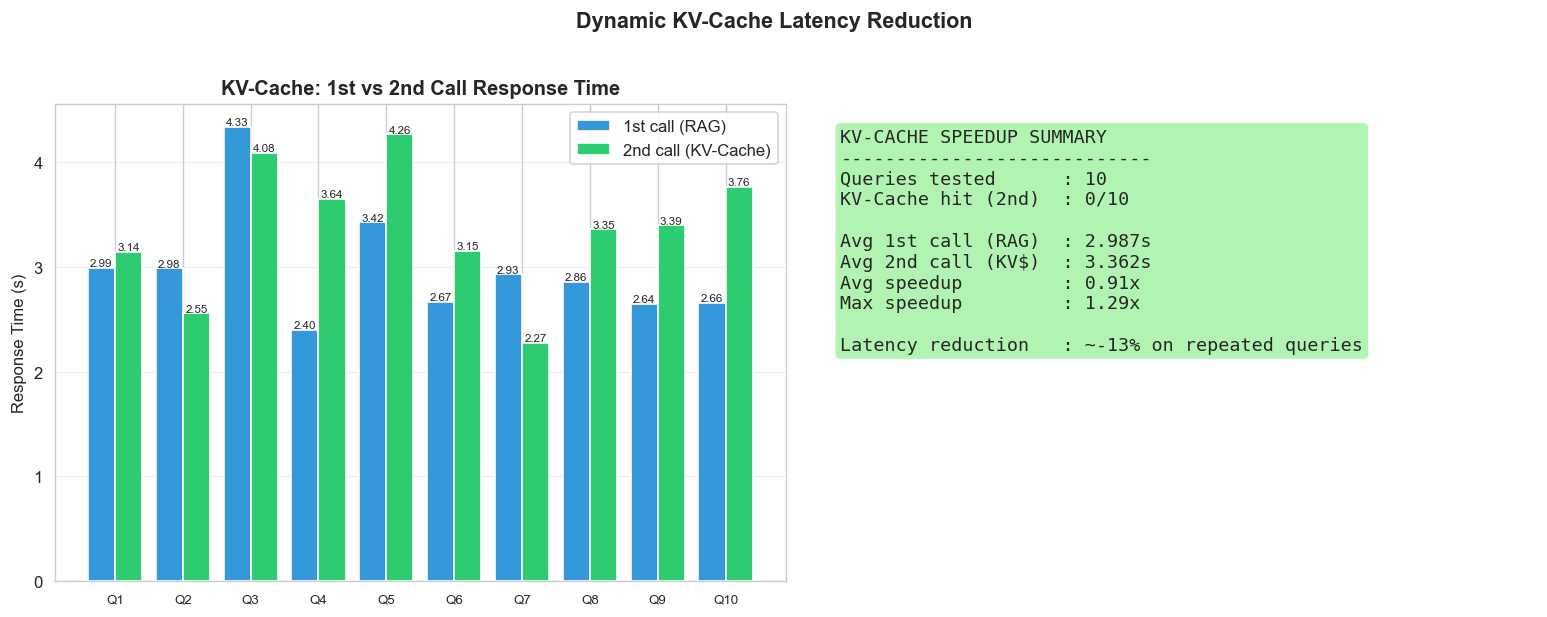

Saved: logs/kvcache_speedup.png

FAQ Static Cache Summary:
  Queries from FAQ cache : 20
  Avg response time      : 0.060s
  Speedup vs RAG avg     : 63.92x


In [24]:
# KV-Cache Speedup Analysis
# scenario_results['KV_Cache']: list of {query, first_time, second_time, speedup, cache_hit_2nd}

kvc_data = scenario_results.get('KV_Cache', [])

if not kvc_data:
    print("No KV_Cache data. All queries were served from the static FAQ cache.")
else:
    first_times  = [d['first_time']  for d in kvc_data]
    second_times = [d['second_time'] for d in kvc_data]
    speedups     = [d['speedup']     for d in kvc_data]

    print(f"KV-Cache Speedup Analysis  ({len(kvc_data)} queries)")
    print("-" * 60)
    print(f"  Avg 1st call (RAG)    : {np.mean(first_times):.3f}s")
    print(f"  Avg 2nd call (KV$)    : {np.mean(second_times):.3f}s")
    print(f"  Avg speedup           : {np.mean(speedups):.2f}x")
    print(f"  Max speedup           : {max(speedups):.2f}x")
    print("-" * 60)

    print(f"\n  {'#':<4} {'Query':<58} {'1st(s)':>7} {'2nd(s)':>7} {'Speedup':>9} {'KV-hit':>7}")
    print("  " + "-" * 92)
    for j, d in enumerate(kvc_data, 1):
        q   = d['query'][:56] + ".." if len(d['query']) > 56 else d['query']
        hit = "YES" if d.get('cache_hit_2nd') else "NO"
        print(f"  {j:<4} {q:<58} {d['first_time']:>7.3f} {d['second_time']:>7.3f} "
              f"{d['speedup']:>8.2f}x {hit:>7}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    x = np.arange(len(kvc_data))
    ax.bar(x - 0.2, first_times,  0.4, label='1st call (RAG)',      color='#3498db')
    ax.bar(x + 0.2, second_times, 0.4, label='2nd call (KV-Cache)', color='#2ecc71')
    ax.set_xticks(x)
    ax.set_xticklabels([f"Q{j+1}" for j in range(len(kvc_data))], fontsize=8)
    ax.set_ylabel('Response Time (s)')
    ax.set_title('KV-Cache: 1st vs 2nd Call Response Time', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    for j, (ft, st) in enumerate(zip(first_times, second_times)):
        ax.text(j - 0.2, ft + 0.015, f'{ft:.2f}', ha='center', fontsize=7)
        ax.text(j + 0.2, st + 0.015, f'{st:.2f}', ha='center', fontsize=7)

    ax = axes[1]
    ax.axis('off')
    hit_count = sum(1 for d in kvc_data if d.get('cache_hit_2nd'))
    reduction = (1 - np.mean(second_times) / np.mean(first_times)) * 100
    summary_txt = (
        "KV-CACHE SPEEDUP SUMMARY\n"
        + "-" * 28 + "\n"
        + f"Queries tested      : {len(kvc_data)}\n"
        + f"KV-Cache hit (2nd)  : {hit_count}/{len(kvc_data)}\n\n"
        + f"Avg 1st call (RAG)  : {np.mean(first_times):.3f}s\n"
        + f"Avg 2nd call (KV$)  : {np.mean(second_times):.3f}s\n"
        + f"Avg speedup         : {np.mean(speedups):.2f}x\n"
        + f"Max speedup         : {max(speedups):.2f}x\n\n"
        + f"Latency reduction   : ~{reduction:.0f}% on repeated queries"
    )
    ax.text(0.05, 0.95, summary_txt, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

    plt.suptitle('Dynamic KV-Cache Latency Reduction', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../logs/kvcache_speedup.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: logs/kvcache_speedup.png")


# FAQ static cache summary
faq_data = scenario_results.get('FAQ', [])
if faq_data:
    a_times = [r['time'] for r in faq_data]
    rag_avg = rag_m['time_avg']
    print(f"\nFAQ Static Cache Summary:")
    print(f"  Queries from FAQ cache : {len(faq_data)}")
    print(f"  Avg response time      : {np.mean(a_times):.3f}s")
    if rag_avg > 0:
        print(f"  Speedup vs RAG avg     : {rag_avg / np.mean(a_times):.2f}x")

## Latency Analysis
Per-query response time, cache hit vs miss, distribusi latency.

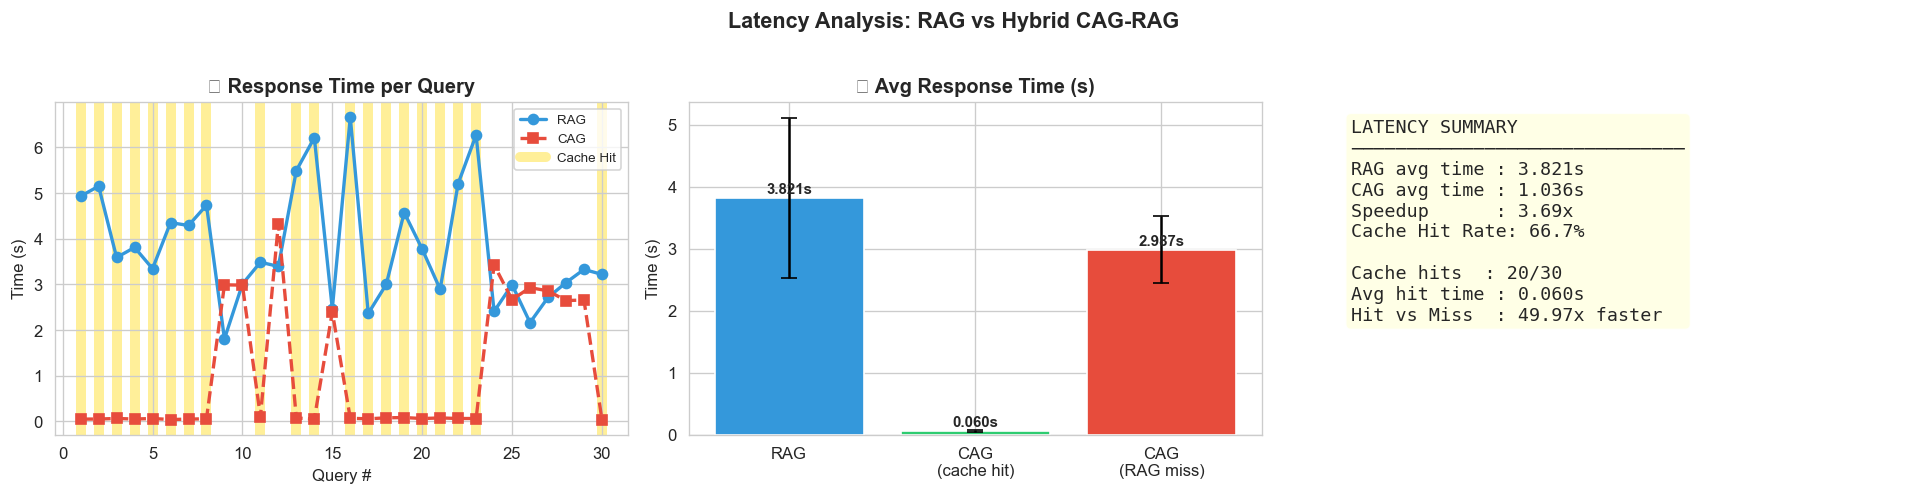

✅ Saved: logs/latency_analysis.png


In [25]:
# 📈 LATENCY ANALYSIS

rag_times  = rag_m['_time']
cag_times  = cag_m['_time'] if cag_m else []
cag_hit_t  = [r['time'] for r in cag_res if r.get('cache')]
cag_miss_t = [r['time'] for r in cag_res if not r.get('cache')]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- 1. Per-query Response Time (line plot) -----
ax = axes[0]
queries_idx = list(range(1, len(rag_times) + 1))
ax.plot(queries_idx, rag_times, 'o-', color='#3498db', label='RAG', linewidth=2)
if cag_times:
    ax.plot(queries_idx[:len(cag_times)], cag_times, 's--', color='#e74c3c', label='CAG', linewidth=2)
    for i, (rt, ct) in enumerate(zip(rag_times, cag_times)):
        if cag_res[i].get('cache'):
            ax.axvline(x=i+1, color='gold', alpha=0.4, linewidth=6, zorder=0, label=('Cache Hit' if i==0 else ''))
ax.set_title('⚡ Response Time per Query', fontweight='bold')
ax.set_xlabel('Query #'); ax.set_ylabel('Time (s)')
ax.legend(fontsize=8)

# --- 2. Average Time Comparison (bar with error bars) -----
ax = axes[1]
sys_names = ['RAG']
means     = [rag_m['time_avg']]
stds      = [rag_m['time_std']]
colors_b  = ['#3498db']
if cag_m:
    if cag_hit_t:
        sys_names += ['CAG\n(cache hit)']
        means.append(round(float(np.mean(cag_hit_t)), 3))
        stds.append(round(float(np.std(cag_hit_t, ddof=1)) if len(cag_hit_t)>1 else 0, 3))
        colors_b.append('#2ecc71')
    if cag_miss_t:
        sys_names += ['CAG\n(RAG miss)']
        means.append(round(float(np.mean(cag_miss_t)), 3))
        stds.append(round(float(np.std(cag_miss_t, ddof=1)) if len(cag_miss_t)>1 else 0, 3))
        colors_b.append('#e74c3c')
bars = ax.bar(sys_names, means, color=colors_b,
              yerr=[s if s > 0 else None for s in stds],
              capsize=5, edgecolor='white')
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f'{v:.3f}s', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_title('📊 Avg Response Time (s)', fontweight='bold')
ax.set_ylabel('Time (s)')

# --- 3. Speedup & CHR summary -----
ax = axes[2]
ax.axis('off')
summary_text = (
    f"LATENCY SUMMARY\n"
    f"{'─'*30}\n"
    f"RAG avg time : {rag_m['time_avg']:.3f}s\n"
)
if cag_m:
    summary_text += (
        f"CAG avg time : {cag_m['time_avg']:.3f}s\n"
        f"Speedup      : {speedup:.2f}x\n"
        f"Cache Hit Rate: {cag_m['chr']:.1f}%\n"
        f"\nCache hits  : {len(cag_hit_t)}/{len(cag_times)}\n"
        f"Avg hit time : {np.mean(cag_hit_t):.3f}s\n" if cag_hit_t else ""
        f"Avg miss time: {np.mean(cag_miss_t):.3f}s\n" if cag_miss_t else ""
    )
    if cag_hit_t and cag_miss_t:
        local_speedup = np.mean(cag_miss_t) / np.mean(cag_hit_t)
        summary_text += f"Hit vs Miss  : {local_speedup:.2f}x faster"
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Latency Analysis: RAG vs Hybrid CAG-RAG', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../logs', exist_ok=True)
plt.savefig('../logs/latency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/latency_analysis.png")

## Quality & Inaccuracy Visualization

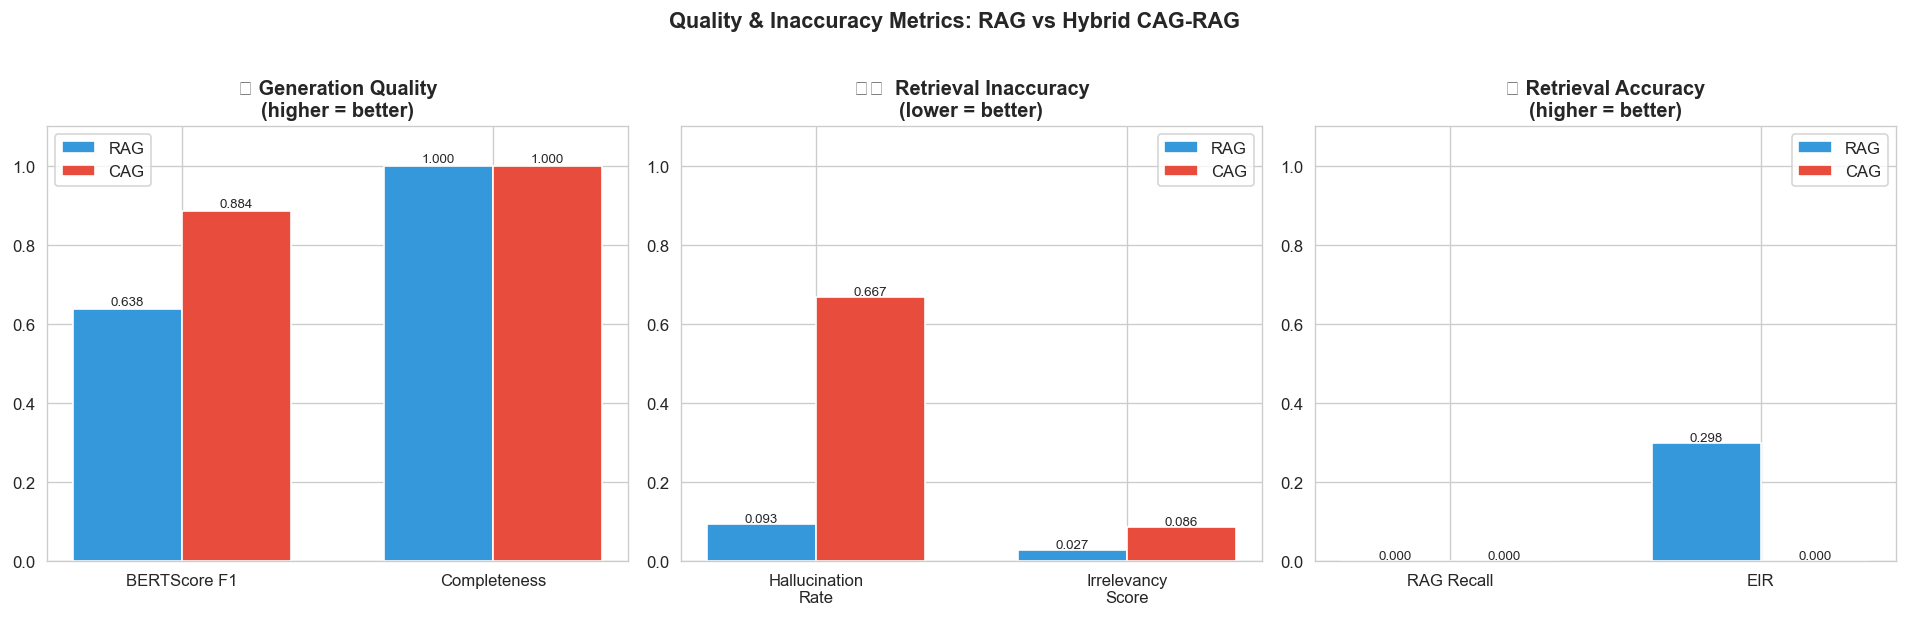

✅ Saved: logs/quality_metrics.png


In [26]:
# 📊 QUALITY & INACCURACY VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sys_names = ['RAG'] + (['CAG'] if cag_m else [])
colors    = ['#3498db', '#e74c3c']

# --- 1. Generation Quality (BERTScore & Completeness) -----
ax = axes[0]
metrics_q   = ['BERTScore F1', 'Completeness']
rag_q_vals  = [rag_m['bert'], rag_m['comp']]
x = np.arange(len(metrics_q)); w = 0.35
ax.bar(x - w/2, rag_q_vals, w, label='RAG', color='#3498db')
if cag_m:
    cag_q_vals = [cag_m['bert'], cag_m['comp']]
    ax.bar(x + w/2, cag_q_vals, w, label='CAG', color='#e74c3c')
    for i, (rv, cv) in enumerate(zip(rag_q_vals, cag_q_vals)):
        ax.text(i - w/2, rv + .01, f'{rv:.3f}', ha='center', fontsize=8)
        ax.text(i + w/2, cv + .01, f'{cv:.3f}', ha='center', fontsize=8)
else:
    for i, rv in enumerate(rag_q_vals):
        ax.text(i, rv + .01, f'{rv:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics_q)
ax.set_title('🎯 Generation Quality\n(higher = better)', fontweight='bold')
ax.set_ylim(0, 1.1); ax.legend()

# --- 2. Retrieval Inaccuracy (lower = better) -----
ax = axes[1]
metrics_i  = ['Hallucination\nRate', 'Irrelevancy\nScore']
rag_i_vals = [rag_m['hall'], rag_m['irr']]
x = np.arange(len(metrics_i))
ax.bar(x - w/2, rag_i_vals, w, label='RAG', color='#3498db')
if cag_m:
    cag_i_vals = [cag_m['hall'], cag_m['irr']]
    ax.bar(x + w/2, cag_i_vals, w, label='CAG', color='#e74c3c')
    for i, (rv, cv) in enumerate(zip(rag_i_vals, cag_i_vals)):
        ax.text(i - w/2, rv + .005, f'{rv:.3f}', ha='center', fontsize=8)
        ax.text(i + w/2, cv + .005, f'{cv:.3f}', ha='center', fontsize=8)
else:
    for i, rv in enumerate(rag_i_vals):
        ax.text(i, rv + .005, f'{rv:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics_i)
ax.set_title('⚠️  Retrieval Inaccuracy\n(lower = better)', fontweight='bold')
ax.set_ylim(0, 1.1); ax.legend()

# --- 3. Retrieval Accuracy (RAG Recall & EIR) -----
ax = axes[2]
metrics_r  = ['RAG Recall', 'EIR']
rag_r_vals = [rag_m['recall'], rag_m['eir']]
x = np.arange(len(metrics_r))
ax.bar(x - w/2, rag_r_vals, w, label='RAG', color='#3498db')
if cag_m:
    cag_r_vals = [cag_m['recall'], cag_m['eir']]
    ax.bar(x + w/2, cag_r_vals, w, label='CAG', color='#e74c3c')
    for i, (rv, cv) in enumerate(zip(rag_r_vals, cag_r_vals)):
        ax.text(i - w/2, rv + .005, f'{rv:.3f}', ha='center', fontsize=8)
        ax.text(i + w/2, cv + .005, f'{cv:.3f}', ha='center', fontsize=8)
else:
    for i, rv in enumerate(rag_r_vals):
        ax.text(i, rv + .005, f'{rv:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics_r)
ax.set_title('🔍 Retrieval Accuracy\n(higher = better)', fontweight='bold')
ax.set_ylim(0, 1.1); ax.legend()

plt.suptitle('Quality & Inaccuracy Metrics: RAG vs Hybrid CAG-RAG',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../logs/quality_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/quality_metrics.png")

## Statistical Significance Testing
Paired t-test (p < 0.05) + Cohen's d effect size.

🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test)
   H0: No difference between RAG and Hybrid CAG-RAG
   H1: Significant difference exists (p < 0.05)

  Metric                   RAG µ   CAG µ   t-stat   p-value      d  Result
  ---------------------------------------------------------------------------
  Response Time           3.8211  1.0356    6.286    0.0000  1.148  ✅ H1 supported
  BERTScore F1            0.6377  0.8845   -7.599    0.0000 -1.387  ✅ H1 supported
  Completeness            1.0000  1.0000      nan       nan  0.000  ❌ not significant
  Hallucination Rate      0.0928  0.6667   -7.535    0.0000 -1.376  ⚠️  sig. but reversed
  Irrelevancy Score       0.0268  0.0863   -2.462    0.0200 -0.450  ⚠️  sig. but reversed
  RAG Recall              0.0000  0.0000      nan       nan  0.000  ❌ not significant
  EIR                     0.2976  0.0000    6.176    0.0000  1.128  ⚠️  sig. but reversed

  Legend: ✅ Hypothesis supported  |  ❌ Not significant  |  ⚠️  Unexpected direction
  α 

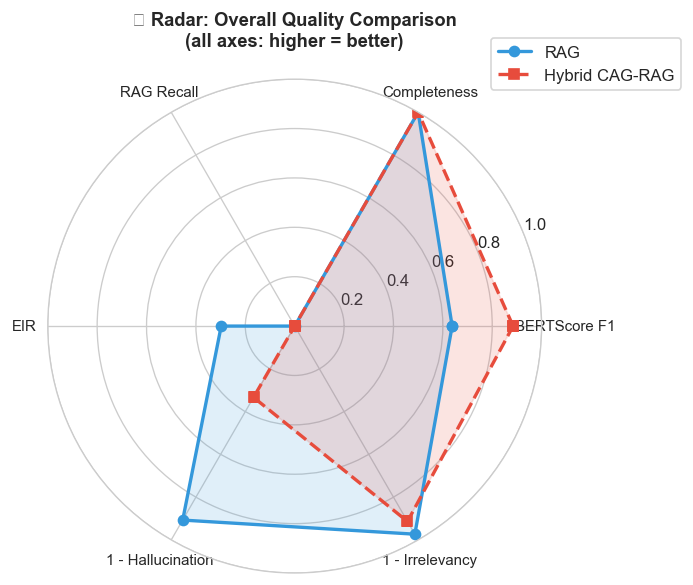

✅ Saved: logs/radar_comparison.png


In [27]:
# 🔬 STATISTICAL SIGNIFICANCE TESTING  (Paired t-test + Cohen's d)
if not cag_m:
    print("⚠️  CAG results not available, skipping statistical tests.")
else:
    print("=" * 65)
    print("🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test)")
    print("   H0: No difference between RAG and Hybrid CAG-RAG")
    print("   H1: Significant difference exists (p < 0.05)")
    print("=" * 65)

    # Metrik yang diuji — arah = 'lower' → CAG harus lebih rendah, 'higher' → CAG harus lebih tinggi
    test_metrics = [
        # (label,              rag_list,           cag_list,           better_direction)
        ("Response Time",      rag_m['_time'],     cag_m['_time'],     "lower"),
        ("BERTScore F1",       rag_m['_bert'],     cag_m['_bert'],     "higher"),
        ("Completeness",       rag_m['_comp'],     cag_m['_comp'],     "higher"),
        ("Hallucination Rate", rag_m['_hall'],     cag_m['_hall'],     "lower"),
        ("Irrelevancy Score",  rag_m['_irr'],      cag_m['_irr'],      "lower"),
        ("RAG Recall",         rag_m['_recall'],   cag_m['_recall'],   "higher"),
        ("EIR",                rag_m['_eir'],      cag_m['_eir'],      "higher"),
    ]

    stat_rows = []
    print(f"\n  {'Metric':<22} {'RAG µ':>7} {'CAG µ':>7} {'t-stat':>8} {'p-value':>9} {'d':>6}  Result")
    print("  " + "-" * 75)

    for lbl, rag_vals, cag_vals, direction in test_metrics:
        if len(rag_vals) < 2 or len(cag_vals) < 2:
            print(f"  {lbl:<22}  (insufficient data — need ≥ 2 queries)")
            continue

        t_stat, p_val = paired_ttest(rag_vals, cag_vals)
        d             = cohens_d(rag_vals, cag_vals)
        rag_mu        = round(float(np.mean(rag_vals)), 4)
        cag_mu        = round(float(np.mean(cag_vals)), 4)
        significant   = not np.isnan(p_val) and p_val < 0.05

        # Check if direction is as expected
        if direction == "lower":
            direction_ok = cag_mu <= rag_mu
        else:
            direction_ok = cag_mu >= rag_mu

        if significant and direction_ok:
            result = "✅ H1 supported"
        elif significant and not direction_ok:
            result = "⚠️  sig. but reversed"
        else:
            result = "❌ not significant"

        print(f"  {lbl:<22} {rag_mu:>7.4f} {cag_mu:>7.4f} {t_stat:>8.3f} {p_val:>9.4f} {d:>6.3f}  {result}")
        stat_rows.append({
            'Metric': lbl, 'RAG_mean': rag_mu, 'CAG_mean': cag_mu,
            't_stat': t_stat, 'p_value': p_val, "Cohen_d": d,
            'significant': significant, 'direction_ok': direction_ok
        })

    print("\n  Legend: ✅ Hypothesis supported  |  ❌ Not significant  |  ⚠️  Unexpected direction")
    print(f"  α = 0.05  |  Effect size: small < 0.2,  medium 0.2–0.8,  large > 0.8")

    # Radar chart for visual comparison
    stat_df = pd.DataFrame(stat_rows)

    # Radar chart
    radar_metrics = ['BERTScore F1', 'Completeness', 'RAG Recall', 'EIR']
    rag_radar  = [rag_m['bert'], rag_m['comp'], rag_m['recall'], rag_m['eir']]
    cag_radar  = [cag_m['bert'], cag_m['comp'], cag_m['recall'], cag_m['eir']]

    # Invert inaccuracy metrics so higher = better on radar
    radar_metrics += ['1 - Hallucination', '1 - Irrelevancy']
    rag_radar  += [1 - rag_m['hall'], 1 - rag_m['irr']]
    cag_radar  += [1 - cag_m['hall'], 1 - cag_m['irr']]

    N   = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    rag_r  = rag_radar + [rag_radar[0]]
    cag_r  = cag_radar + [cag_radar[0]]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, rag_r, 'o-', color='#3498db', linewidth=2, label='RAG')
    ax.fill(angles, rag_r, alpha=0.15, color='#3498db')
    ax.plot(angles, cag_r, 's--', color='#e74c3c', linewidth=2, label='Hybrid CAG-RAG')
    ax.fill(angles, cag_r, alpha=0.15, color='#e74c3c')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title('📡 Radar: Overall Quality Comparison\n(all axes: higher = better)',
                 fontsize=11, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig('../logs/radar_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: logs/radar_comparison.png")

## Save & Export

In [28]:
# Save & Export All Results

import json
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
os.makedirs('../logs', exist_ok=True)

# 1. Summary metrics JSON
summary_export = {
    'timestamp':    ts,
    'dataset_size': len(dataset),
    'rag': {k: v for k, v in rag_m.items() if not k.startswith('_') and k != 'per_query'},
    'cag': ({k: v for k, v in cag_m.items() if not k.startswith('_') and k != 'per_query'}
            if cag_m else None),
    'speedup_factor': round(speedup, 4) if cag_m else None,
    'scenario_faq': {
        'total_hits': len(scenario_results.get('FAQ', [])),
        'avg_time':   (round(float(np.mean([r['time'] for r in scenario_results['FAQ']])), 3)
                       if scenario_results.get('FAQ') else None),
    },
    'scenario_kvcache': {
        'total_tested': len(scenario_results.get('KV_Cache', [])),
        'avg_speedup':  (round(float(np.mean([d['speedup']
                                               for d in scenario_results['KV_Cache']])), 3)
                         if scenario_results.get('KV_Cache') else None),
    },
}

json_path = f'../logs/eval_summary_{ts}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary_export, f, indent=2, ensure_ascii=False)
print(f"Summary JSON     : {json_path}")

# 2. Per-query CSV — RAG
if rag_m['per_query']:
    rag_csv = f'../logs/eval_rag_perquery_{ts}.csv'
    pd.DataFrame(rag_m['per_query']).to_csv(rag_csv, index=False)
    print(f"RAG per-query    : {rag_csv}")

# 3. Per-query CSV — CAG
if cag_m and cag_m['per_query']:
    cag_csv = f'../logs/eval_cag_perquery_{ts}.csv'
    pd.DataFrame(cag_m['per_query']).to_csv(cag_csv, index=False)
    print(f"CAG per-query    : {cag_csv}")

# 4. KV-Cache scenario CSV
if scenario_results.get('KV_Cache'):
    kvc_csv = f'../logs/eval_kvcache_{ts}.csv'
    pd.DataFrame(scenario_results['KV_Cache']).to_csv(kvc_csv, index=False)
    print(f"KV-Cache scenario: {kvc_csv}")

# 5. Statistical results CSV
if cag_m and 'stat_df' in dir():
    stat_csv = f'../logs/eval_stats_{ts}.csv'
    stat_df.to_csv(stat_csv, index=False)
    print(f"Statistics       : {stat_csv}")

# Key Findings
print("\n" + "=" * 65)
print("KEY FINDINGS  —  Hybrid CAG-RAG vs Pure RAG")
print("=" * 65)

print(f"\n  RQ1 LATENCY")
print(f"    RAG avg time   : {rag_m['time_avg']:.3f}s +/- {rag_m['time_std']:.3f}s")
if cag_m:
    print(f"    CAG avg time   : {cag_m['time_avg']:.3f}s +/- {cag_m['time_std']:.3f}s")
    print(f"    Speedup factor : {speedup:.2f}x  ({'OK' if speedup > 1 else 'NO IMPROVEMENT'})")
    print(f"    Cache Hit Rate : {cag_m['chr']:.1f}%")
    kvc = scenario_results.get('KV_Cache', [])
    if kvc:
        print(f"    KV-Cache speedup (avg): {np.mean([d['speedup'] for d in kvc]):.2f}x")

print(f"\n  RQ2 INACCURACY")
if cag_m:
    hall_d = rag_m['hall'] - cag_m['hall']
    irr_d  = rag_m['irr']  - cag_m['irr']
    rel_d  = cag_m['rel']  - rag_m['rel']
    print(f"    Hallucination  RAG={rag_m['hall']:.4f}  CAG={cag_m['hall']:.4f}  delta={hall_d:+.4f}")
    print(f"    Irrelevancy    RAG={rag_m['irr']:.4f}  CAG={cag_m['irr']:.4f}  delta={irr_d:+.4f}")
    print(f"    Relevance      RAG={rag_m['rel']:.4f}  CAG={cag_m['rel']:.4f}  delta={rel_d:+.4f}")

    print(f"\n  GENERATION QUALITY")
    print(f"    BERTScore F1   RAG={rag_m['bert']:.4f}  CAG={cag_m['bert']:.4f}  delta={cag_m['bert']-rag_m['bert']:+.4f}")
    print(f"    Completeness   RAG={rag_m['comp']:.4f}  CAG={cag_m['comp']:.4f}  delta={cag_m['comp']-rag_m['comp']:+.4f}")
    print(f"    Exact Match    RAG={rag_m['em']:.4f}  CAG={cag_m['em']:.4f}  delta={cag_m['em']-rag_m['em']:+.4f}")
    print(f"    Token F1       RAG={rag_m['token_f1']:.4f}  CAG={cag_m['token_f1']:.4f}  delta={cag_m['token_f1']-rag_m['token_f1']:+.4f}")

print("\nEvaluation complete.")
print(f"Outputs saved to: logs/")

Summary JSON     : ../logs/eval_summary_20260309_144454.json
RAG per-query    : ../logs/eval_rag_perquery_20260309_144454.csv
CAG per-query    : ../logs/eval_cag_perquery_20260309_144454.csv
KV-Cache scenario: ../logs/eval_kvcache_20260309_144454.csv
Statistics       : ../logs/eval_stats_20260309_144454.csv

KEY FINDINGS  —  Hybrid CAG-RAG vs Pure RAG

  RQ1 LATENCY
    RAG avg time   : 3.821s +/- 1.288s
    CAG avg time   : 1.036s +/- 1.437s
    Speedup factor : 3.69x  (OK)
    Cache Hit Rate : 66.7%
    KV-Cache speedup (avg): 0.91x

  RQ2 INACCURACY
    Hallucination  RAG=0.0928  CAG=0.6667  delta=-0.5739
    Irrelevancy    RAG=0.0268  CAG=0.0863  delta=-0.0595
    Relevance      RAG=0.9731  CAG=0.9137  delta=-0.0594

  GENERATION QUALITY
    BERTScore F1   RAG=0.6377  CAG=0.8845  delta=+0.2468
    Completeness   RAG=1.0000  CAG=1.0000  delta=+0.0000
    Exact Match    RAG=0.0000  CAG=0.6667  delta=+0.6667
    Token F1       RAG=0.1119  CAG=0.7147  delta=+0.6028

Evaluation complete